<div style="background-color: #0D1B2A; padding: 20px; border-radius: 8px; border-left: 5px solid #00B4D8; color: #E0E1DD; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h1 style="margin-top: 0; font-size: 28px; font-weight: bold; color: #00B4D8; letter-spacing: 0.5px;">BLUE NOTEBOOK</h1>
    <p style="margin-bottom: 0; font-size: 15px; color: #E0E1DD; opacity: 0.9;">
        Loading PACE AOP suite and exploring covariance between phytoplankton diversity and optical diversity. IOCCG SLS, by Ivona
    </p>
</div>


<div style="background-color: #D1E8FF; padding: 20px; border-radius: 8px; color: #111111; font-family: sans-serif;">
    <p>In the latest IOCCG report, <a href="https://ioccg.org/wp-content/uploads/2026/04/report_22_hyperspectral_v1.pdf" target="_blank" style="color: #0056b3; text-decoration: underline;">"A Scientific Roadmap of Aquatic Hyperspectral Remote Sensing: Overview of Status, Challenges and Future Perspectives"</a>, in the chapter dedicated to the exploration of phytoplankton community structure with hyperspectral tools, the authors identify several "New science questions."</p>
    <p>One of these questions is: <em>"Is there a quantifiable relationship between spectral diversity (e.g., richness of optical signatures) and phytoplankton community diversity, and can this relationship reveal novel microbial biogeographic patterns or previously undetected bloom dynamics?"</em></p>
    <p>Let's try to use PACE data to start exploring this idea.</p>
</div>


We begin by adding the external packages to your enviroment. If you are running this in google colab, you will have everything except for earthaccess and cartopy. If you are at cryocloud, you should have cartopy and earthaccess in your enviroment so comment this out. If you are somewhere elsewhere, just uncoment the whole line and run it all.

In [ ]:
!pip install earthaccess cartopy #matplotlib numpy xarray

Let us then load the libraries you will need for this notebook.

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthaccess
from xarray.backends.api import open_datatree

<div style="background-color: #D1E8FF; padding: 20px; border-radius: 8px; color: #111111; font-family: sans-serif;">
    <h2>Let's sniff around some optical indices</h2>
    <p>The <a href="https://oceancolor.gsfc.nasa.gov/files/atbd/atbd-obdaac-apparent-visible-wavelength.pdf" target="_blank" style="color: #0056b3; text-decoration: underline;">Apparent Visible Wavelength (AVW)</a> algorithm returns the weighted harmonic mean of the visible-range (400–700 nm) remote sensing reflectance ($R_{rs}$) wavelengths, in units of nanometers.</p>
    <p>The AVW is an optical water classification index, representing a one-dimensional geophysical metric that is inherently correlated to $R_{rs}$ spectral shape; check out <a href="https://doi.org/10.1016/j.rse.2020.111900" target="_blank" style="color: #0056b3; text-decoration: underline;">Vandermeulen et al. 2020</a>.</p>
    <p>It lives within the PACE L2 AOP suite, so we will go back to the same scene on May 6th, 2026 and see what it looks like.</p>
</div>


This is assuming that you have previously logged into `earthaccess` on this platform and that it has remembered your password and login. If not, please go to this [notebook](https://nasa.github.io/oceandata-notebooks/notebooks/oci/oci_data_access.html) and follow the directions.


In [3]:
auth = earthaccess.login(persist=True)

We are streaming data only, not downloading. Once data is loaded into the data tree, you can explore the datatree in the structure printout below, and see all the pretty parameters you have.

In [6]:
results = earthaccess.search_data(
    short_name='PACE_OCI_L2_AOP_NRT',
    granule_name='PACE_OCI.20260505T173406.L2.OC_AOP.V3_2.NRT.nc'
)
paths = earthaccess.open(results)

# Stream the file directly into memory
datatree = xr.open_datatree(paths[-1])
dataset_avw = datatree["geophysical_data"]["avw"]
dataset_avw

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.DataArray 'avw' (number_of_lines: 1710, pixels_per_line: 1272)> Size: 9MB
[2175120 values with dtype=float32]
Dimensions without coordinates: number_of_lines, pixels_per_line
Attributes:
    long_name:  Apparent Visible Wavelength
    units:      nm
    valid_min:  400.0
    valid_max:  700.0
    reference:  Vandermeulen, R. A., Mannino, A., Craig, S.E., Werdell, P.J.,...

In [7]:
for item in ("longitude", "latitude"):
    dataset_avw[item] = datatree["navigation_data"][item]
dataset_avw


<xarray.DataArray 'avw' (number_of_lines: 1710, pixels_per_line: 1272)> Size: 9MB
[2175120 values with dtype=float32]
Coordinates:
    longitude  (number_of_lines, pixels_per_line) float32 9MB ...
    latitude   (number_of_lines, pixels_per_line) float32 9MB ...
Dimensions without coordinates: number_of_lines, pixels_per_line
Attributes:
    long_name:  Apparent Visible Wavelength
    units:      nm
    valid_min:  400.0
    valid_max:  700.0
    reference:  Vandermeulen, R. A., Mannino, A., Craig, S.E., Werdell, P.J.,...

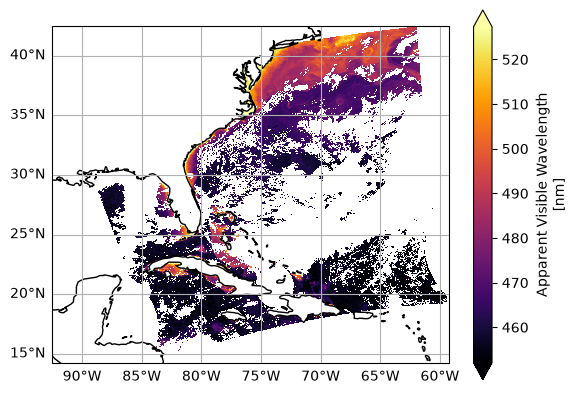

In [9]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
im = dataset_avw.plot(x="longitude", y="latitude", cmap="viridis", robust=True, ax=ax)
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
ax.coastlines()
plt.show()

<div style="background-color: #D1E8FF; padding: 20px; border-radius: 8px; color: #111111; font-family: sans-serif;">
    <h2 style="margin-top: 0;">Let's play with some phytoplankton data!</h2>
    <p>The **Spectral Derivative Pigments (SDP)** algorithm returns the concentration of thirteen phytoplankton pigments (in $\text{mg m}^{-3}$). It uses an empirical relationship derived from field data between analytical measurements of phytoplankton pigment concentrations and the second derivative of hyperspectral remote sensing reflectance residuals ([Catlett & Siegel, 2018](https://doi.org/10.1002/2017JC013195); [Kramer, Siegel, Maritorena, & Catlett, 2022](https://doi.org/10.1016/j.rse.2021.112879)).</p>
    <p>This product should soon be available globally through normal NASA distribution channels.</p>
    <p>In the meantime, you can explore the <a href="https://github.com/max-danenhower/pace-rrs-inversions-pigments" target="_blank" style="color: #0044CC; text-decoration: underline; font-weight: bold;">SDP Git repository</a> to run it yourself or retrain the algorithm with your local data!</p>
    <p>A Jupyter Notebook version will also soon be hosted at our <a href="https://nasa.github.io/oceandata-notebooks/" target="_blank" style="color: #0044CC; text-decoration: underline; font-weight: bold;">Help Hub</a>. For now, simply download the single file to start playing with the data!</p>
</div>


In [ ]:
nc_filename = 'PACE_OCI.20260505T173406.L2.OC_AOP.V3_2.NRT_SDP_pigments.nc'
datatree = open_datatree(nc_filename)
datatree

In [ ]:
dataset = xr.merge(datatree.to_dict().values())
dataset

In [ ]:
import cartopy.crs as ccrs


variables = [
    "chla", "chlb", "chlc", "zea", "dvchla", "butfuco", 
    "hexfuco", "allo", "neo", "viola", "fuco", "chlc3", "perid"
]


fig, axs = plt.subplots(4, 4, figsize=(20, 16), subplot_kw={"projection": crs})

# Iterate over all 16 subplots
for i, ax in enumerate(axs.flat):
    if i < len(variables):
        var = variables[i]
        
       
        data = dataset[var]
        lon = dataset["longitude"]
        lat = dataset["latitude"]

        vmin = np.nanpercentile(data, 0)
        vmax = np.nanpercentile(data, 98)

        # Add land features
        ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', alpha=0.5)
        ax.add_feature(cfeature.LAKES, facecolor='lightgray', alpha=0.7)

        im = ax.pcolormesh(
            lon, lat, data, 
            cmap="viridis", 
            shading="auto", 
            zorder=10,
            vmin=vmin,    
            vmax=vmax,
            transform=ccrs.PlateCarree() # Ensures coordinates map correctly
        )

       
        ax.gridlines(
            draw_labels=["left", "bottom"],
            linewidth=0.5,
            color="gray",
            alpha=0.5,
            linestyle="--",
        )
        
        # Set title as the variable name
        ax.set_title(var.upper())
        
        # Set map extent based on bbox bounds
        ax.set_xlim(bbox[0], bbox[2])
        ax.set_ylim(bbox[1], bbox[3])

        cbar = fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.50, pad=0.04)
        cbar.set_label(f"{var} (mg m$^{{-3}}$)")  
        
    else:
        # Hide any unused subplots
        ax.set_visible(False)

plt.tight_layout()

# Save the figure - optional
plt.savefig('SDP_all_pigments_map_linear.png', dpi=250, bbox_inches='tight')

plt.show()

Very pretty - but lets lower down the dimensions and calculate a single diversity index. 

## Shannon-Wiener Diversity Index ($H'$)

The **Shannon-Wiener Index** is a widely used metric in ecology to measure species diversity within a community. It accounts for both **richness** (the number of species present) and **evenness** (how equally individuals are distributed among those species).

### Mathematical Formula

$$H' = -\sum_{i=1}^{S} p_i \ln(p_i)$$

Where:
* **$H'$**: The Shannon-Wiener Diversity Index.
* **$S$**: The total number of species in the community (species richness).
* **$p_i$**: The proportion of individuals belonging to the $i$-th species ($p_i = \frac{n_i}{N}$).
* **$\ln$**: The natural logarithm (log base $e$).

### Key Insights
* **Higher values** indicate greater diversity and a more even distribution of species.
* **Lower values** indicate low diversity, often dominated by a single species.
* **Zero value ($H'=0$)** means the community contains only one species.

---

### Application: Phytoplankton Pigment Proxies

For this exploratory analysis, we use **8 diagnostic pigments** as operational markers for distinct taxonomic groups:

* **fuco**: Diatoms
* **perid**: Dinoflagellates
* **hexfuco**: Prymnesiophytes
* **butfuco**: Pelagophytes
* **allo**: Cryptophytes
* **chlb**: Green Algae
* **zea**: *Synechococcus*
* **dvchla**: *Prochlorococcus*

> **Methodological Note:** In reality, some of these pigments are shared across multiple taxonomic groups rather than being strictly specific to one. This calculation serves as an initial, exploratory proxy to visualize general spatial patterns of pigment diversity and to have fun!


In [ ]:
marker_pigments = ['fuco', 'perid', 'hexfuco', 'butfuco', 'allo', 'chlb', 'zea', 'dvchla']

# First, calculate the total concentration of all marker pigments combined
total_markers = sum(dataset[m].where(dataset[m] > 0, 0) for m in marker_pigments)

# Create an empty array to hold the diversity index
shannon_index = xr.zeros_like(total_markers)

# Loop through each group to calculate its contribution to the index
for m in marker_pigments:
    # Calculate the proportion (p_i) of this specific group
    p_i = dataset[m].where(dataset[m] > 0, 0) / total_markers
    
    # Calculate p_i * ln(p_i). We use .where(p_i > 0) to avoid math errors from ln(0)
    entropy = p_i * np.log(p_i.where(p_i > 0))
    
    # Add to the running total (ignoring NaNs)
    shannon_index -= entropy.fillna(0)

# Mask out areas where there were virtually no pigments to avoid false positives
shannon_index = shannon_index.where(total_markers > 0.0001)

# Extract coordinates for mapping
lon = dataset['longitude']
lat = dataset['latitude']

# ==========================================
# 3. Plot the Diversity Map
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Add land and borders
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', alpha=0.5, zorder=3)

# Plot the Shannon Index
# Using 'magma' colormap: dark = low diversity, bright yellow/white = high diversity
im = ax.pcolormesh(
    lon, lat, shannon_index, 
    cmap="magma", 
    shading="auto", 
    zorder=1,
    transform=ccrs.PlateCarree()
)

# Set map extent (Ensure bbox is defined earlier in your notebook)
# bbox format: [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([bbox[0], bbox[2], bbox[1], bbox[3]], crs=ccrs.PlateCarree())

# Add Gridlines
gl = ax.gridlines(draw_labels=["left", "bottom"], linewidth=0.5, color="gray", alpha=0.5, linestyle="--", zorder=4)

# Add Colorbar
cbar = fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.8, pad=0.04)
cbar.set_label("Shannon-Wiener Diversity Index ($H'$)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('SDP_Shannon_index.png', dpi=300, bbox_inches='tight')


Coolio. Now it's your turn to play! :)

Here are a couple of ideas:

1. How would you explore correlation between optical index (avw) and diversity index (Shannon)? Maybe linear? Maybe some crazy something non linear? Try multiple things.
2. Are there any optical indices you know of -> you can use AOPs, IOPs or any other measurments avaliable - check out the [PACE data table](https://pace.oceansciences.org/data_table.htm) to see which data you can get. 
